In [1]:
import numpy as np
import pandas as pd
import datetime
import yfinance as yf
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# For importing universal scripts
import sys
import os
# Go up two levels from the subfolder
sys.path.append(os.path.abspath(".."))
from indicators_returns import final_df #Universal script for indicator set and actuals
import importlib
import indicators_returns
importlib.reload(indicators_returns)
from indicators_returns import final_df
import gc
from sklearn.metrics import (fbeta_score, accuracy_score, f1_score, 
                             confusion_matrix, balanced_accuracy_score, recall_score, matthews_corrcoef, precision_score)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, StratifiedKFold
from xgboost import XGBClassifier
import math
import pickle
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler, StratifiedKFold

tags = pd.read_csv('../Indicator_Selection_Pipeline/Finalization/tags_cons.csv') 

def extract(ticker, returns, cat_cols_all, windows=[10, 25]):

    import os
    # point this at an existing directory in your project
    os.chdir('/Users/brettchase/Documents/Fracturion/Feature_Set_Construction_Testing')
    
    df = final_df(ticker, returns)
    df = df.iloc[:-101].replace([np.inf, -np.inf], 0)#

    df = df.sort_index(ascending=True)
    # Exponential Moving Average
    ema_cols = {
        f"{col}_EMA{w}": df[col].ewm(span=w, adjust=False).mean()
        for w in windows
        for col in cat_cols_all
    }
    # 3) merge them back into one dict
    new_cols = {**ema_cols}

    # 4) concatenate onto your original df
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)    
    df = df.sort_index(ascending=False)
    
    return df

raw_all = tags['Indicator'][tags['Type'] == 'Raw']
returns = [5, 10, 15, 20, 25, 35, 45]
df = extract('QQQ', returns, raw_all, windows=[10,25])

# By category × velocity
duration_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
duration_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
duration_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
trend_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
trend_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
trend_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
trend_ratio_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
trend_ratio_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
trend_ratio_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
volatility_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
volatility_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
volatility_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
volatility_fast_EMA10 = [f"{col}_EMA10" for col in volatility_fast]
momentum_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
momentum_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
momentum_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
momentum_fast_EMA10 = [f"{col}_EMA10" for col in momentum_fast]
lag_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'lag') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
win_rates = [col for col in df.columns if col.startswith('wr_')]

# Start with must include columns (slope)

In [22]:
def print_metrics(metrics):
        for thresh, metric_values in metrics.items():
            print(f"  Threshold {thresh}: {metric_values}")
  
def optimize_splits_new(df_indicators, df_predict, thresh, opt, arch, test_size, withold, return_metrics=False):
    
    def train_and_evaluate(model, param_grid, X_train, y_train, X_test, y_test, opt, thresh, iter):

        def run_cv(cv_split, iter):

            model.set_params(n_jobs=1)
            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                scoring=opt,
                cv=cv_split,
                n_jobs=-1,
                n_iter=iter,
                random_state=42
            )
            
            random_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
            best_model = random_search.best_estimator_
            y_prob = best_model.predict_proba(X_test)
            postot = y_test.sum()
            negtot = len(y_test) - y_test.sum()

            metrics = {}
            for t in thresh:
                y_pred_thresh = (y_prob[:, 1] > t).astype(int)
                y_pred_thresh[y_prob[:, 0] > t] = 0
                filtered_indices = (y_prob[:, 1] > t) | (y_prob[:, 0] > t)

                if filtered_indices.sum() > 0:
                    y_test_valid = y_test[filtered_indices]
                    y_pred_valid = y_pred_thresh[filtered_indices]
                    posprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=1, zero_division=0), 2)
                    negprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=0, zero_division=0), 2)
                    poscnt = sum(y_pred_valid == 1)
                    negcnt = sum(y_pred_valid == 0)
                    posrec = round(posprec * poscnt / postot, 2)
                    negrec = round(negprec * negcnt / negtot, 2)
                    metrics[t] = {
                    "Len": len(y_test),
                    "PC": poscnt,
                    "NC": negcnt,
                    "PP": posprec,
                    "PR": posrec,
                    "NP": negprec,
                    "NR": negrec,
                    "PosFb": round((3*posprec*posrec)/((2*posrec)+(1*posprec)),3),
                    "NegFb": round((3*negprec*negrec)/((2*negrec)+(1*negprec)),3),
                    }
                    metrics[t] = {k: np.nan_to_num(v, nan=0.0) for k, v in metrics[t].items()}
                
            return metrics, best_model

        # Try all split values and pick best
        best_result = None
        best_score = -float("inf")

        split_values = [3, 4, 5]

        for splits in split_values:

            cv_split = TimeSeriesSplit(n_splits=splits)

            metrics, model = run_cv(cv_split, iter)

            # scoring method: average of PosFb and NegFb at first threshold
            t = list(metrics.keys())[0]
            avg_score = (metrics[t]["PosFb"] + metrics[t]["NegFb"]) / 2

            if avg_score > best_score:
                best_score = avg_score
                best_result = (metrics, model, splits)

        print(f"Best CV split: {best_result[2]} (score={best_score.round(2)})")
        
        return best_result[0], best_result[1], best_score

    X_test = df_indicators.iloc[:test_size].copy()
    y_test = df_predict.iloc[:test_size].copy()
    
    if withold == 'N':
        test_size = 0
    df_indicators = df_indicators.iloc[test_size:].sort_index(ascending=True).copy()
    df_predict = df_predict.iloc[test_size:].sort_index(ascending=True).copy()

    X_train = df_indicators.copy()
    y_train = df_predict.copy()

    counts = y_train.value_counts()
    negf = counts.get(0, 0)
    posf = counts.get(1, 1)  # prevent division by zero
    scale_pos_weight = negf / posf

    # Deep
    xgboost_hyperparameters = {
        'max_depth': [6, 9, 12],          # Still fairly deep
        'learning_rate': [0.01, 0.05],    # Lower rates
        'min_child_weight': [4, 7, 9, 12],   # More conservative splits
        'subsample': [0.7, 0.8, 0.9],     
        'colsample_bytree': [0.75, 0.85], 
        'colsample_bylevel': [0.7, 0.8, 0.9],
        'colsample_bynode': [0.7, 0.8, 0.9],    
        'gamma': [0.1, 0.3, 0.5],         
        'alpha': [0.1, 0.5, 1.0], 
        'lambda': [5, 10, 15],            
        'n_estimators': [800], 
        'early_stopping_rounds': [10]
        }

    iter = 50

    # Train and evaluate models
    xg_metrics, best_xg_model, best_score = train_and_evaluate(XGBClassifier(random_state=42), xgboost_hyperparameters, X_train, y_train, X_test, y_test, opt, thresh, iter)
    #record_validation_metrics(xg_metrics, arch='shallow', horizon=r, model_name=name)
    #savearch(best_xg_model, r, name, arch)
    metrics = list(xg_metrics.values())[0]
    pscore = metrics.get('PosFb', 0)
    nscore = metrics.get('NegFb', 0)
    
    print_metrics(xg_metrics)

    if return_metrics:
        return xg_metrics, best_xg_model
    else:
        #print_metrics(xg_metrics)
        return best_xg_model, best_score

def optimize_rs(df_indicators, df_predict, thresh, opt, arch, test_size, withold, return_metrics=False):
    
    def train_and_evaluate(model, param_grid, X_train, y_train, X_tune, y_tune, X_test, y_test, opt, thresh, iter):

        def run_cv(cv_split, iter):

            model.set_params(n_jobs=1)
            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                scoring=opt,
                cv=cv_split,
                n_jobs=-1,
                n_iter=iter,
                random_state=42
            )
            
            random_search.fit(X_train, y_train, eval_set=[(X_tune, y_tune)], verbose=False)
            best_model = random_search.best_estimator_
            best_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
            y_prob = best_model.predict_proba(X_test)
            postot = y_test.sum()
            negtot = len(y_test) - y_test.sum()

            metrics = {}
            for t in thresh:
                y_pred_thresh = (y_prob[:, 1] > t).astype(int)
                y_pred_thresh[y_prob[:, 0] > t] = 0
                filtered_indices = (y_prob[:, 1] > t) | (y_prob[:, 0] > t)

                if filtered_indices.sum() > 0:
                    y_test_valid = y_test[filtered_indices]
                    y_pred_valid = y_pred_thresh[filtered_indices]
                    posprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=1, zero_division=0), 2)
                    negprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=0, zero_division=0), 2)
                    poscnt = sum(y_pred_valid == 1)
                    negcnt = sum(y_pred_valid == 0)
                    posrec = round(posprec * poscnt / postot, 2)
                    negrec = round(negprec * negcnt / negtot, 2)
                    metrics[t] = {
                    "Len": len(y_test),
                    "PC": poscnt,
                    "NC": negcnt,
                    "PP": posprec,
                    "PR": posrec,
                    "NP": negprec,
                    "NR": negrec,
                    "PosFb": round((3*posprec*posrec)/((2*posrec)+(1*posprec)),3),
                    "NegFb": round((3*negprec*negrec)/((2*negrec)+(1*negprec)),3),
                    }
                    metrics[t] = {k: np.nan_to_num(v, nan=0.0) for k, v in metrics[t].items()}
                
            return metrics, best_model

        # Try all split values and pick best
        best_result = None
        best_score = -float("inf")

        split_values = [3, 4, 5]

        for splits in split_values:

            cv_split = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42)

            metrics, model = run_cv(cv_split, iter)

            # scoring method: average of PosFb and NegFb at first threshold
            t = list(metrics.keys())[0]
            avg_score = (metrics[t]["PosFb"] + metrics[t]["NegFb"]) / 2

            if avg_score > best_score:
                best_score = avg_score
                best_result = (metrics, model, splits)

        print(f"Best CV split: {best_result[2]} (score={best_score.round(2)})")
        
        return best_result[0], best_result[1], best_score

    X_test = df_indicators.iloc[:test_size].copy()
    y_test = df_predict.iloc[:test_size].copy()
    
    if withold == 'N':
        test_size = 0
    df_indicators = df_indicators.iloc[test_size:].sort_index(ascending=True).copy()
    df_predict = df_predict.iloc[test_size:].sort_index(ascending=True).copy()
    X_train, X_tune, y_train, y_tune = train_test_split(df_indicators, df_predict, test_size=0.3, random_state=42, shuffle=True)

    counts = y_train.value_counts()
    negf = counts.get(0, 0)
    posf = counts.get(1, 1)  # prevent division by zero
    scale_pos_weight = negf / posf

    # Deep
    xgboost_hyperparameters = {
        'max_depth': [6, 9],          # Still fairly deep
        'learning_rate': [0.01, 0.05],    # Lower rates
        'min_child_weight': [7, 10],   # More conservative splits
        'subsample': [0.7, 0.8, 0.9],     
        'colsample_bytree': [0.75, 0.85], 
        'colsample_bylevel': [0.7, 0.8, 0.9],
        'colsample_bynode': [0.7, 0.8, 0.9],    
        'gamma': [0.1, 0.3, 0.5],         
        'alpha': [0.1, 0.5, 1.0],         
        'lambda': [5, 10, 15],            
        'n_estimators': [800], 
        'early_stopping_rounds': [10],
        #'eval_metric': ['error']
        }

    iter = 50

    # Train and evaluate models
    xg_metrics, best_xg_model, best_score = train_and_evaluate(XGBClassifier(random_state=42), xgboost_hyperparameters, X_train, y_train, X_tune, y_tune, 
                                                               X_test, y_test, opt, thresh, iter)
    #record_validation_metrics(xg_metrics, arch='shallow', horizon=r, model_name=name)
    #savearch(best_xg_model, r, name, arch)
    metrics = list(xg_metrics.values())[0]
    pscore = metrics.get('PosFb', 0)
    nscore = metrics.get('NegFb', 0)
    
    print_metrics(xg_metrics)

    if return_metrics:
        return xg_metrics, best_xg_model
    else:
        #print_metrics(xg_metrics)
        return best_xg_model, best_score

def save(best_model, days, model, ticker, arch):
    
    directory = f'../Models/Ensemble_{ticker}'  # Saves to the current working directory
    os.makedirs(directory, exist_ok=True)
    
    with open(os.path.join(directory, str(model)+'_xgboost_'+str(days)+str(arch)+'new.pkl'), 'wb') as file_object:
        pickle.dump(best_model, file_object)

    print('Models Saved for '+(ticker)+'_'+str(model)+' '+str(days)+'_'+' Returns')

def savers(best_model, days, model, ticker, arch, ext):
    
    directory = f'../Models/Ensemble_{ticker}'  # Saves to the current working directory
    os.makedirs(directory, exist_ok=True)
    
    with open(os.path.join(directory, str(model)+'_xgboost_'+str(days)+str(arch)+str(ext)+'.pkl'), 'wb') as file_object:
        pickle.dump(best_model, file_object)

    print('Models Saved for '+(ticker)+'_'+str(model)+' '+str(days)+' Returns')

def add_cyclic_seasonality(
    df: pd.DataFrame,
    date_col: str = 'Date',
    add_weekly: bool = True,
    add_month: bool = True,
    add_quarter: bool = True,
    add_year: bool = True,
    add_day_of_year: bool = False,
    mode: str = 'calendar',          # 'trading', 'calendar', or 'both'
    prefix: str = 'cyc_'
) -> pd.DataFrame:
    """
    Add cyclic (sin/cos) seasonality features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a date column.
    date_col : str
        Name of the datetime column.
    add_weekly, add_month, add_quarter, add_year, add_day_of_year : bool
        Toggles for which seasonal cycles to create.
    mode : {'trading','calendar','both'}
        - 'trading': position = trading-day index / trading-days-in-period (resets at dataset slice start)
        - 'calendar': position = calendar progress within period (day-based; retains true mid-period phase)
        - 'both': create both sets (with suffixes _trade and _cal)
    prefix : str
        Prefix for created feature names.

    Returns
    -------
    pd.DataFrame
        Copy of df with new seasonality features appended (original row order preserved).
    """
    if date_col not in df.columns:
        raise ValueError(f"'{date_col}' not found in DataFrame.")
    if mode not in {'trading', 'calendar', 'both'}:
        raise ValueError("mode must be 'trading', 'calendar', or 'both'.")

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    # Preserve original order / index
    original_index = out.index
    work = out.sort_values(date_col).reset_index(drop=False)
    idx_col = work.columns[0]

    # Precompute basic date parts
    work['_year']    = work[date_col].dt.year
    work['_month']   = work[date_col].dt.month
    work['_quarter'] = work[date_col].dt.quarter
    work['_weekday'] = work[date_col].dt.weekday
    work['_doy']     = work[date_col].dt.dayofyear
    work['_is_leap'] = work[date_col].dt.is_leap_year

    # ---------- WEEKLY (trading week: Mon-Fri) ----------
    if add_weekly:
        week_pos = work['_weekday'] / 5.0  # Monday=0.0, Friday≈0.8 (if only Mon-Fri present)
        work[f'{prefix}week_sin'] = np.sin(2 * np.pi * week_pos)
        work[f'{prefix}week_cos'] = np.cos(2 * np.pi * week_pos)

    # Helper to safely divide
    def _safe_div(num, den):
        return np.where(den == 0, 0.0, num / np.where(den == 0, 1, den))

    # ---------- MONTH ----------
    if add_month:
        if mode in {'trading', 'both'}:
            grp_m = [work['_year'], work['_month']]
            idx_m = work.groupby(grp_m).cumcount()
            cnt_m = work.groupby(grp_m)[date_col].transform('count')
            pos_m_trade = _safe_div(idx_m, cnt_m)
            work[f'{prefix}month_trade_sin'] = np.sin(2 * np.pi * pos_m_trade)
            work[f'{prefix}month_trade_cos'] = np.cos(2 * np.pi * pos_m_trade)

        if mode in {'calendar', 'both'}:
            dom = work[date_col].dt.day           # 1..days_in_month
            dim = work[date_col].dt.days_in_month
            pos_m_cal = _safe_div(dom - 1, dim - 1)
            work[f'{prefix}month_sin'] = np.sin(2 * np.pi * pos_m_cal)
            work[f'{prefix}month_cos'] = np.cos(2 * np.pi * pos_m_cal)

    # ---------- QUARTER ----------
    if add_quarter:
        if mode in {'trading', 'both'}:
            grp_q = [work['_year'], work['_quarter']]
            idx_q = work.groupby(grp_q).cumcount()
            cnt_q = work.groupby(grp_q)[date_col].transform('count')
            pos_q_trade = _safe_div(idx_q, cnt_q)
            work[f'{prefix}quarter_trade_sin'] = np.sin(2 * np.pi * pos_q_trade)
            work[f'{prefix}quarter_trade_cos'] = np.cos(2 * np.pi * pos_q_trade)

        if mode in {'calendar', 'both'}:
            q = work['_quarter']
            y = work['_year']
            quarter_start = pd.to_datetime({'year': y, 'month': (q - 1) * 3 + 1, 'day': 1})
            quarter_end = quarter_start + pd.offsets.QuarterEnd(0)
            day_in_q = (work[date_col] - quarter_start).dt.days
            days_q = (quarter_end - quarter_start).dt.days
            pos_q_cal = _safe_div(day_in_q, days_q)
            work[f'{prefix}quarter_sin'] = np.sin(2 * np.pi * pos_q_cal)
            work[f'{prefix}quarter_cos'] = np.cos(2 * np.pi * pos_q_cal)

    # ---------- YEAR ----------
    if add_year:
        if mode in {'trading', 'both'}:
            grp_y = work['_year']
            idx_y = work.groupby(grp_y).cumcount()
            cnt_y = work.groupby(grp_y)[date_col].transform('count')
            pos_y_trade = _safe_div(idx_y, cnt_y)
            work[f'{prefix}year_trade_sin'] = np.sin(2 * np.pi * pos_y_trade)
            work[f'{prefix}year_trade_cos'] = np.cos(2 * np.pi * pos_y_trade)

        if mode in {'calendar', 'both'}:
            doy = work['_doy']
            year_len = np.where(work['_is_leap'], 366, 365)
            pos_y_cal = _safe_div(doy - 1, year_len - 1)
            work[f'{prefix}year_sin'] = np.sin(2 * np.pi * pos_y_cal)
            work[f'{prefix}year_cos'] = np.cos(2 * np.pi * pos_y_cal)

    # ---------- DAY OF YEAR (explicit) ----------
    if add_day_of_year:
        year_len = np.where(work['_is_leap'], 366, 365)
        work[f'{prefix}doy_sin'] = np.sin(2 * np.pi * work['_doy'] / year_len)
        work[f'{prefix}doy_cos'] = np.cos(2 * np.pi * work['_doy'] / year_len)

    # Drop temp columns
    temp_cols = [c for c in work.columns if c.startswith('_')]
    work = work.drop(columns=temp_cols)

    # Identify newly created features
    new_cols = [c for c in work.columns if c not in out.columns and c != idx_col]

    # Map back to original order
    work = work.set_index(idx_col)
    out[new_cols] = work.loc[original_index, new_cols]

    return out

def perm_importance(all_perm_dfs, ext):

    # Combine all permutation importance DataFrames
    current_perm_df = pd.concat(all_perm_dfs, ignore_index=True)

    # Apply the retention logic per group
    def apply_retention_logic(group):
        group = group.copy()
        group["drop_flag"] = group["importance_mean"] <= 0.01

        total = len(group)
        retained = (~group["drop_flag"]).sum()
        min_retained = int(np.ceil(total * 0.45))

        if retained < min_retained:
            top_feats = group.sort_values(by="importance_mean", ascending=False).head(min_retained)["feature"]
            group["drop_flag"] = ~group["feature"].isin(top_feats)

        return group

    # Apply group-wise adjustment by model_name, arch, horizon
    current_perm_df = current_perm_df.groupby(
        ["model_name", "arch", "horizon"], group_keys=False
    ).apply(apply_retention_logic)

    # Build feature map from retained features
    curr_feature_map = (
        current_perm_df[~current_perm_df["drop_flag"]]
        .groupby(["model_name", "arch", "horizon"])["feature"]
        .apply(list)
        .to_dict()
    )

    # Save
    with open(f"curr_feature_map_v{ext}.pkl", "wb") as f:
        pickle.dump(curr_feature_map, f)

    print('Saved curr_feature_map')

weekly = ['cyc_week_sin', 'cyc_week_cos']
monthly = ['cyc_month_sin', 'cyc_month_cos']
quarterly = ['cyc_quarter_sin', 'cyc_quarter_cos']
yearly = ['cyc_year_sin', 'cyc_year_cos']
all_seasons = ['cyc_week_sin', 'cyc_week_cos', 'cyc_month_sin', 'cyc_month_cos', 'cyc_quarter_sin', 'cyc_quarter_cos',
               'cyc_year_sin', 'cyc_year_cos']
slopes = ['Close_slope10', 'Close_slope25', 'Close_slope50']

selected_combos = {
    "h_5": {
        'duration_slow+trend_ratio_slow+momentum_fast_EMA10': duration_slow+trend_ratio_slow+momentum_fast_EMA10,
        'lag_fast+trend_slow+momentum_moderate': lag_fast+trend_slow+momentum_moderate,
        'duration_slow+trend_ratio_slow+momentum_moderate': duration_slow+trend_ratio_slow+momentum_moderate,
        #'duration_slow+trend_ratio_slow+momentum_fast': duration_slow+trend_ratio_slow+momentum_fast,
        'trend_ratio_moderate+momentum_moderate+momentum_fast_EMA10': trend_ratio_moderate+momentum_moderate+momentum_fast_EMA10,
    },
    "h_10": {
        'duration_moderate+duration_fast+trend_ratio_slow': duration_moderate+duration_fast+trend_ratio_slow,
        'duration_slow+duration_fast+trend_fast': duration_slow+duration_fast+trend_fast,
        #'duration_moderate+trend_slow+trend_ratio_fast': duration_moderate+trend_slow+trend_ratio_fast,
        'duration_slow+trend_ratio_slow+trend_ratio_moderate': duration_slow+trend_ratio_slow+trend_ratio_moderate,
        'trend_slow+trend_fast+trend_ratio_fast': trend_slow+trend_fast+trend_ratio_fast,
    },
    "h_15": {
        'duration_moderate+duration_fast+trend_slow': duration_moderate+duration_fast+trend_slow,
        'trend_ratio_slow+momentum_moderate+momentum_fast_EMA10': trend_ratio_slow+momentum_moderate+momentum_fast_EMA10,
        'trend_slow+trend_ratio_slow+trend_ratio_fast': trend_slow+trend_ratio_slow+trend_ratio_fast,
        'duration_slow+duration_fast+trend_ratio_moderate': duration_slow+duration_fast+trend_ratio_moderate,
        'trend_fast+trend_ratio_moderate+volatility_fast': trend_fast+trend_ratio_moderate+volatility_fast,
    },
    "h_20": {
        'lag_fast+trend_slow+volatility_moderate': lag_fast+trend_slow+volatility_moderate,
        'lag_fast+trend_slow+trend_moderate': lag_fast+trend_slow+trend_moderate,
        'duration_moderate+trend_ratio_slow+momentum_moderate': duration_moderate+trend_ratio_slow+momentum_moderate,
        'duration_slow+duration_moderate+trend_ratio_slow': duration_slow+duration_moderate+trend_ratio_slow,
        'duration_slow+trend_moderate+trend_ratio_moderate': duration_slow+trend_moderate+trend_ratio_moderate,
    },
    "h_25": {
        'lag_fast+duration_moderate+volatility_fast_EMA10': lag_fast+duration_moderate+volatility_fast_EMA10,
        'lag_fast+trend_slow+volatility_moderate': lag_fast+trend_slow+volatility_moderate,
        'duration_slow+duration_moderate+trend_ratio_slow': duration_slow+duration_moderate+trend_ratio_slow,
        'duration_slow+trend_moderate+trend_ratio_moderate': duration_slow+trend_moderate+trend_ratio_moderate,
        'duration_fast+trend_moderate+trend_ratio_slow': duration_fast+trend_moderate+trend_ratio_slow,
    },
    "h_35": {
        'lag_fast+trend_fast+trend_ratio_moderate': lag_fast+trend_fast+trend_ratio_moderate,
        'lag_fast+volatility_fast+momentum_slow': lag_fast+volatility_fast+momentum_slow,
        'lag_fast+trend_ratio_fast+momentum_slow': lag_fast+trend_ratio_fast+momentum_slow,
        #'duration_slow+trend_ratio_slow+trend_ratio_moderate': duration_slow+trend_ratio_slow+trend_ratio_moderate,
        'duration_slow+trend_slow+trend_ratio_slow': duration_slow+trend_slow+trend_ratio_slow,
    },
    "h_45": {
        'lag_fast+trend_moderate+trend_ratio_slow': lag_fast+trend_moderate+trend_ratio_slow,
        'lag_fast+trend_ratio_slow+volatility_moderate': lag_fast+trend_ratio_slow+volatility_moderate,
        'duration_slow+duration_moderate+trend_fast': duration_slow+duration_moderate+trend_fast,
        'duration_slow+duration_moderate+volatility_moderate': duration_slow+duration_moderate+volatility_moderate,
        'momentum_moderate+momentum_fast_EMA10+all_seasons': momentum_moderate+momentum_fast_EMA10+all_seasons,
    },
    "h_50": {
        'lag_fast+win_rates': lag_fast + win_rates
    }
}

def get_model_set(horizon):
    if horizon in [1, 2, 3, 5]:
        key = "h_5"
    elif horizon in [10]:
        key = "h_10"
    elif horizon in [15]:
        key = "h_15"
    elif horizon in [20]:
        key = "h_20" 
    elif horizon in [25]:
        key = "h_25"
    elif horizon in [35]:
        key = "h_35"
    elif horizon in [45]:
        key = "h_45"
    else:
        raise ValueError(f"Unsupported horizon: {horizon}")
    
    return selected_combos[key]

"""
def get_model_set(horizon):
    if horizon in [5]:
        key = "h_50"
    elif horizon in [10]:
        key = "h_50"
    elif horizon in [15]:
        key = "h_50"
    elif horizon in [20]:
        key = "h_50" 
    elif horizon in [25]:
        key = "h_50"
    elif horizon in [35]:
        key = "h_50"
    elif horizon in [45]:
        key = "h_50"
    else:
        raise ValueError(f"Unsupported horizon: {horizon}")
    
    return selected_combos[key]
"""

'\ndef get_model_set(horizon):\n    if horizon in [5]:\n        key = "h_50"\n    elif horizon in [10]:\n        key = "h_50"\n    elif horizon in [15]:\n        key = "h_50"\n    elif horizon in [20]:\n        key = "h_50" \n    elif horizon in [25]:\n        key = "h_50"\n    elif horizon in [35]:\n        key = "h_50"\n    elif horizon in [45]:\n        key = "h_50"\n    else:\n        raise ValueError(f"Unsupported horizon: {horizon}")\n    \n    return selected_combos[key]\n'

In [33]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(invalid='ignore', divide='ignore')
ticker = 'QQQ'
thresh = [.5, .55]
results = []
returns = [1, 2, 3, 5, 10, 15, 20, 25, 35, 45]
arch = 'deep'
withold = 'Y'
test_size = 160
test_sizes = [230, 180, 140]
run_perm = "N"
save_models = 'Y'
offset = 0
lbs = [8, 10]
date = '10-27'
periods = [1, 2, 3, 5, 10, 15, 20, 25, 35, 45]
df_raw = extract(ticker, returns, raw_all, windows=[10,25])

for test_size in test_sizes:

    ext = f'{date}-{test_size}'

    if run_perm != "Y":
        with open(f"curr_feature_map_v{ext}.pkl", "rb") as f:
                feature_map = pickle.load(f)
    else: all_perm_dfs = []
        
    for r in returns:

        selected_models = get_model_set(r)
            
        for name, cols in selected_models.items():

            best_score = -float("inf")
            best_model = None
            best_lb = None
            df = df_raw.copy()
            df = add_cyclic_seasonality(df, date_col='Date', add_weekly=True, add_month=True,
                                        add_quarter=True, add_year=True, add_day_of_year=False,
                                        mode='calendar',    # or 'trading' or 'both'
                                        prefix='cyc_')    
                
            for lb in lbs:

                record_length = 245 * lb
                df_ph = df.iloc[offset:offset+record_length].copy()
                df_ph = df_ph.iloc[r:].copy()
                
                return_col = f"Return_{r}"
                return_perc_col = f"Return%_{r}"
                model_key = f"QQQ_{r}"

                rets = df_ph[return_perc_col].copy()
                # Split into negative and positive returns
                neg = rets[rets < 0]
                pos = rets[rets > 0]
                # Calculate dynamic thresholds
                neg_cutoff = neg.nlargest(int(len(neg) * 0.05)).min()  # least negative of top 10% in magnitude
                pos_cutoff = pos.nsmallest(int(len(pos) * 0.1)).max()  # smallest positive of top 10% in magnitude
                
                filtered = df_ph[(df_ph[f'Return%_{r}'] < neg_cutoff) | (df_ph[f'Return%_{r}'] > pos_cutoff)].copy()
                counts = filtered[return_col].value_counts()
                negf = counts.get(0, 0)
                posf = counts.get(1, 1)  # prevent division by zero
                #print(f'{posf} | {negf}')
                scale_pos_weight = negf / posf

                # Choose evaluation metric
                opt = 'matthews_corrcoef'

                # Combine features with return column, drop missing
                original_cols = list(dict.fromkeys(cols))

                regime_col = ['Regime_Vol']

                if run_perm == 'Y':
                    prod_cols = original_cols

                else: 
                    prod_cols = feature_map.get((name, arch, r), original_cols)
                    print(f"{len(original_cols)} | {len(prod_cols)}")

                used_cols = prod_cols + [return_col]
                df_model = filtered[used_cols].dropna()
                
                df_indicators = df_model[prod_cols]
                df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
                df_predict = df_model[return_col]
                
                print(f"Results for Regime: {lb}lb | {len(df_ph)}records | {name} | Test: {df_ph['Date'].iloc[0].strftime('%Y-%m-%d')}-{df_ph['Date'].iloc[test_size].strftime('%Y-%m-%d')} | {ticker}_{r}")
                best_xg_model, score = optimize_splits_new(df_indicators, df_predict, thresh, opt, arch, test_size, withold, return_metrics=False)
                #best_xg_model, score = optimize_rs(df_indicators, df_predict, thresh, opt, arch, test_size, withold, return_metrics=False)

                if score > best_score:

                    best_score = score
                    best_model = best_xg_model
                    best_lb = lb
            
            if best_model is not None:

                print(f"Best model: lb={best_lb}, score={round(best_score,3)}")
                
                if save_models == 'Y': 
                    savers(best_model, r, name, ticker, arch, ext)
                
                if run_perm == 'Y':

                    perm_size = test_size
                    X_test = df_indicators.iloc[:perm_size].copy()
                    y_test = df_predict.iloc[:perm_size].copy()
                    
                    # Run permutation importance
                    perm = permutation_importance(best_model, X_test, y_test, n_repeats=100, random_state=None, n_jobs=-1)

                    # Organize into a DataFrame
                    perm_df = pd.DataFrame({
                        'feature': df_indicators.columns,
                        'importance_mean': perm.importances_mean,
                        'importance_std': perm.importances_std,
                        'arch': arch,
                        'horizon': r,
                        'model_name': name
                    })

                    all_perm_dfs.append(perm_df)

                    print(f"Permutation Importance — {name} | QQQ_{r}")
                
                print('---------------------------')

    if run_perm == 'Y': perm_importance(all_perm_dfs, ext)

16 | 8
Results for Regime: 8lb | 1959records | duration_slow+trend_ratio_slow+momentum_fast_EMA10 | Test: 2025-10-28-2024-11-25 | QQQ_1
Best CV split: 4 (score=0.53)
  Threshold 0.5: {'Len': 230, 'PC': 186, 'NC': 44, 'PP': 0.61, 'PR': 0.85, 'NP': 0.55, 'NR': 0.25, 'PosFb': 0.673, 'NegFb': 0.393}
  Threshold 0.55: {'Len': 230, 'PC': 95, 'NC': 3, 'PP': 0.65, 'PR': 0.46, 'NP': 0.67, 'NR': 0.02, 'PosFb': 0.571, 'NegFb': 0.057}
16 | 8
Results for Regime: 10lb | 2449records | duration_slow+trend_ratio_slow+momentum_fast_EMA10 | Test: 2025-10-28-2024-11-25 | QQQ_1
Best CV split: 4 (score=0.44)
  Threshold 0.5: {'Len': 230, 'PC': 204, 'NC': 26, 'PP': 0.58, 'PR': 0.88, 'NP': 0.42, 'NR': 0.11, 'PosFb': 0.654, 'NegFb': 0.217}
  Threshold 0.55: {'Len': 230, 'PC': 85, 'NC': 0, 'PP': 0.64, 'PR': 0.41, 'NP': 0.0, 'NR': 0.0, 'PosFb': 0.539, 'NegFb': 0.0}
Best model: lb=8, score=0.533
Models Saved for QQQ_duration_slow+trend_ratio_slow+momentum_fast_EMA10 1 Returns
---------------------------
41 | 19
R

# Velocity x Category Combo Groupings

In [27]:
ticker = 'QQQ'
model_dir = f'../Models/Ensemble_{ticker}'
thresh = .5
arch_types = ['deep']
lb = 5
returns = [1, 2, 3, 5, 10, 15, 20, 25, 35, 45]
combined_df = pd.DataFrame()
extst = ['10-27-230', '10-27-180', '10-27-140']
exts = ['10-27-230', '10-27-180', '10-27-140', 170, '10-08']

def extract(ticker, returns, cat_cols_all, windows=[10, 25]):

    import os
    from indicators_returns import final_df #Universal script for indicator set and actuals
    import importlib
    import indicators_returns
    importlib.reload(indicators_returns)
    from indicators_returns import final_df
    # point this at an existing directory in your project
    os.chdir('/Users/brettchase/Documents/Fracturion/Feature_Set_Construction_Testing')
    
    df = final_df(ticker, returns)
    df = df.iloc[:-101].replace([np.inf, -np.inf], 0)#

    df = df.sort_index(ascending=True)
    # Exponential Moving Average
    ema_cols = {
        f"{col}_EMA{w}": df[col].ewm(span=w, adjust=False).mean()
        for w in windows
        for col in cat_cols_all
    }
    # 3) merge them back into one dict
    new_cols = {**ema_cols}

    # 4) concatenate onto your original df
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)    
    df = df.sort_index(ascending=False)
    
    return df

df = extract(ticker, returns, raw_all, windows=[10,25])

def submodel(thresh, ext, df):

        upper = thresh
        lower = 1 - upper

        # Placeholder for final predictions
        combined_predictions = {}
        record_length = lb * 245
        df = df.iloc[:record_length]
        df = add_cyclic_seasonality(df, 
                                    date_col='Date',
                                    add_weekly=True,
                                    add_month=True,
                                    add_quarter=True,
                                    add_year=True,
                                    add_day_of_year=False,
                                    mode='calendar',    # or 'trading' or 'both'
                                    prefix='cyc_')

        # Iterate through each return horizon
        for r in returns:
        
            df_ph = df.copy()

            # Create base prediction matrix with Date and Close
            pred_matrix = df_ph[['Date', 'Close']].copy()

            for arch in arch_types:
            
                selected_models = get_model_set(r)
                    
                # all index-combos of length r
                for name, original_cols in selected_models.items():

                    #cols = original_cols
                    cols = feature_map.get((name, arch, r), original_cols)
                    
                    df_features = df_ph[cols].copy()
                    df_features = df_features.replace([np.inf, -np.inf], 0)

                    # XGBoost prediction
                    xgb_path = os.path.join(model_dir, f"{name}_xgboost_{r}{arch}{ext}.pkl")
                    #print(xgb_path)
                    #xgb_path = os.path.join(model_dir, f"{name}_xgboost_{r}{arch}all.pkl")
                    if os.path.exists(xgb_path):
                        with open(xgb_path, 'rb') as f:
                            model_xgb = pickle.load(f)
                            #print(f"{xgb_path} | {model_xgb.get_booster().best_iteration}")
                        prob_xgb = model_xgb.predict_proba(df_features)[:, 1]
                        col_name_xgb = f"{name}_xgb_{r}{arch}"
                        pred_matrix[col_name_xgb] = np.where(
                            prob_xgb > upper, prob_xgb,
                            np.where(prob_xgb < lower, prob_xgb - 1, 0)
                        )

                        signed_pred = np.where(
                            prob_xgb > upper, prob_xgb,
                            np.where(prob_xgb < lower, prob_xgb - 1, 0)
                        )

                    # Final summed prediction across models
                    pred_cols = [col for col in pred_matrix.columns if col not in ['Date', 'Close'] and not col.startswith('sum_')
                                 and not col.startswith('w_sum_') and not col.startswith('weighted_')]
                    pred_matrix[f"sum_{r}"] = pred_matrix[pred_cols].sum(axis=1)

                    combined_predictions[r] = pred_matrix

        aggr_df = None

        for r, df_preds in combined_predictions.items():

            cols_to_merge = [col for col in df_preds.columns if col not in ['Date', 'Close']]
            df_preds_renamed = df_preds[['Date', 'Close'] + cols_to_merge].copy()

            if aggr_df is None:
                aggr_df = df_preds_renamed
            else:
                aggr_df = pd.merge(aggr_df, df_preds_renamed, on=['Date', 'Close'], how='outer')

        sub_model_df = aggr_df.copy()
        for r in returns:
            sub_model_df[f"sum_{r}_{ext}"] = sub_model_df[f"sum_{r}"]

        return sub_model_df, model_xgb, cols

for ext in exts:
    with open(f"curr_feature_map_v{ext}.pkl", "rb") as f:
            feature_map = pickle.load(f)

    """
    sub_model_df, model_xgb, cols = submodel(thresh, ext)
    sub_model_df[['Date', 'Close', f'sum_5_{ext}', f'sum_10_{ext}', f'sum_15_{ext}', f'sum_20_{ext}', 
                f'sum_25_{ext}', f'sum_35_{ext}', f'sum_45_{ext}']].sort_index(ascending=False).head(45).round(3).reset_index()
    """
    # Run submodel
    sub_model_df, model_xgb, cols = submodel(thresh, ext, df)

    # Select only needed columns
    cols_to_merge = ['Date', 'Close', 
                    f'sum_5_{ext}', f'sum_10_{ext}', f'sum_15_{ext}', 
                    f'sum_20_{ext}', f'sum_25_{ext}', f'sum_35_{ext}', f'sum_45_{ext}']
    sub_model_df = sub_model_df[cols_to_merge]

    if combined_df.empty:
        combined_df = sub_model_df.copy()
    else:
        combined_df = combined_df.merge(sub_model_df, on=['Date', 'Close'], how='outer')

#combined_df.sort_index(ascending=False).head(5).round(3).reset_index()
        
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

rs = [15]
for r in returns:
    final_df = combined_df.sort_index(ascending=False).head(r).round(3).reset_index().drop(columns='index', errors='ignore').copy()
    cols = [col for col in final_df.columns if col.startswith(f'sum_{r}')]
    print(final_df[['Date', 'Close'] + cols].head(3))
    
    plt.figure(figsize=(12,6))

    # line for Close
    plt.plot(final_df['Date'], final_df['Close'], color='black', linewidth=1, alpha=0.6, label='Close')

    # all sum_5_x columns
    sum_cols = [c for c in final_df.columns if c.startswith(f'sum_{r}_')]
    offsets = np.linspace(-0.3, 0.3, len(sum_cols))  # small horizontal offsets

    for i, col in enumerate(sum_cols):
        vals = final_df[col]
        colors = np.where(vals >= 0, 'blue', 'red')     # up = blue, down = red
        sizes = np.abs(vals) * 60                       # scale magnitude
        # apply slight horizontal offset to separate columns visually
        plt.scatter(final_df['Date'] + np.timedelta64(int(offsets[i]*24), 'h'),
                    final_df['Close'],
                    s=sizes, c=colors, alpha=0.55, edgecolor='k', linewidths=0.4, label=col)

    # custom legend
    legend_elements = [
        Patch(facecolor='blue', edgecolor='k', label='Positive (Up)'),
        Patch(facecolor='red', edgecolor='k', label='Negative (Down)'),
        Line2D([], [], color='black', linewidth=1.5, label='Close')
    ]
    plt.legend(handles=legend_elements + [Line2D([], [], color='none', label=col) for col in sum_cols],
            title='Legend', loc='best')

    plt.xlabel('Date')
    plt.xticks(final_df['Date'], rotation=45, ha='right')
    plt.ylabel('Close')
    plt.title('Close with Prediction Magnitude and Direction')
    plt.tight_layout()
    plt.show()
    

ValueError: feature_names mismatch: ['Min_60_Rows_Since', 'Min_120_Rows_Since', 'num_days_100', 'num_days_200', '100_SMA_200', '50_EMA_100', '50_SMA_200', 'OBV_ROC10_EMA10'] ['Min_60_Rows_Since', 'Min_120_Rows_Since', 'num_days_100', 'num_days_200', '100_SMA_200', '100_EMA_200', '50_SMA_100', '50_EMA_100', '25_EMA_50', '50_SMA_200', '50_EMA_200', 'VROC_10_EMA10', 'VROC_5_EMA10', 'VROC_3_EMA10', 'OBV_ROC10_EMA10', 'OBV_ROC5_EMA10']
training data did not have the following fields: VROC_3_EMA10, OBV_ROC5_EMA10, 100_EMA_200, 25_EMA_50, VROC_10_EMA10, 50_EMA_200, 50_SMA_100, VROC_5_EMA10

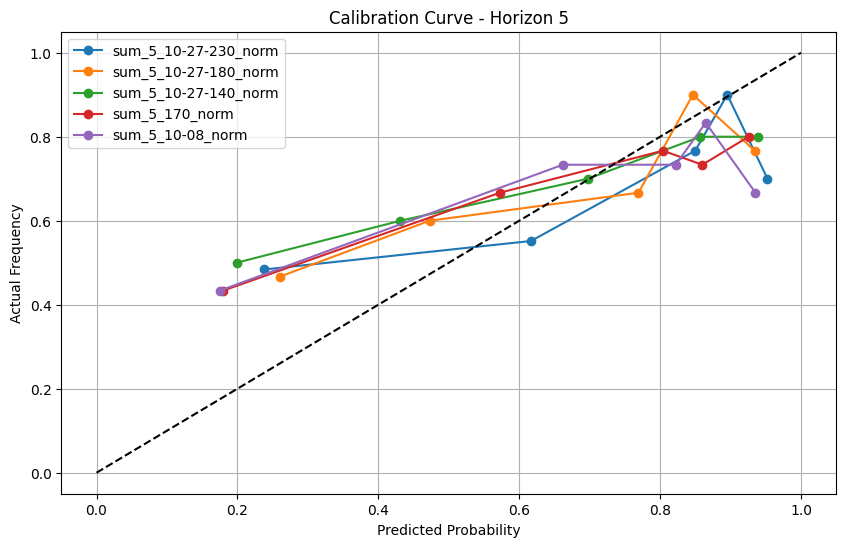

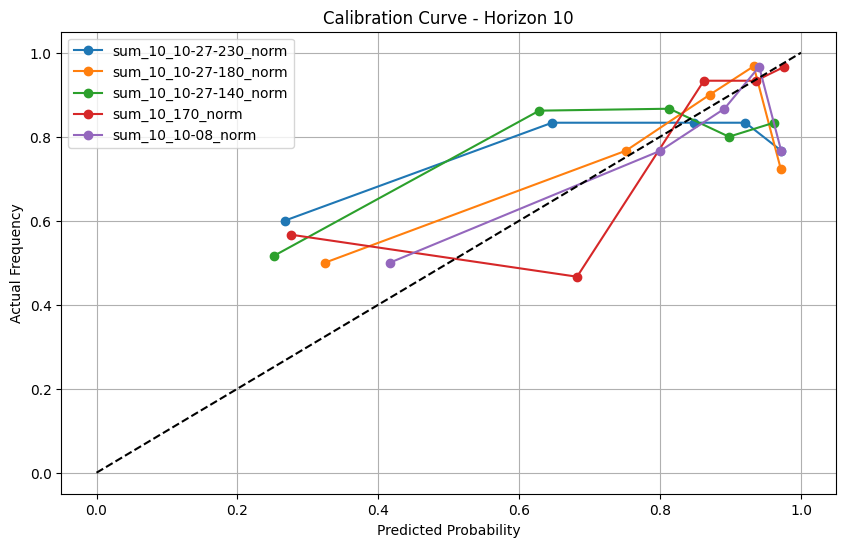

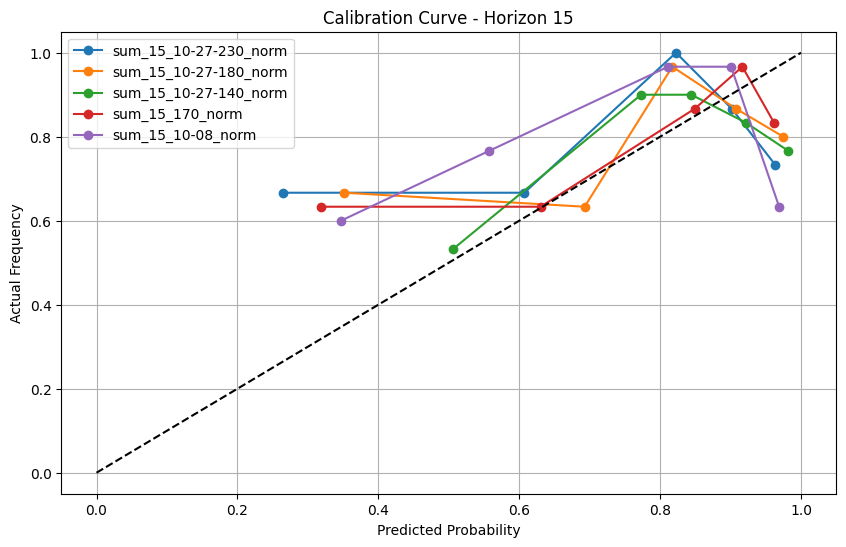

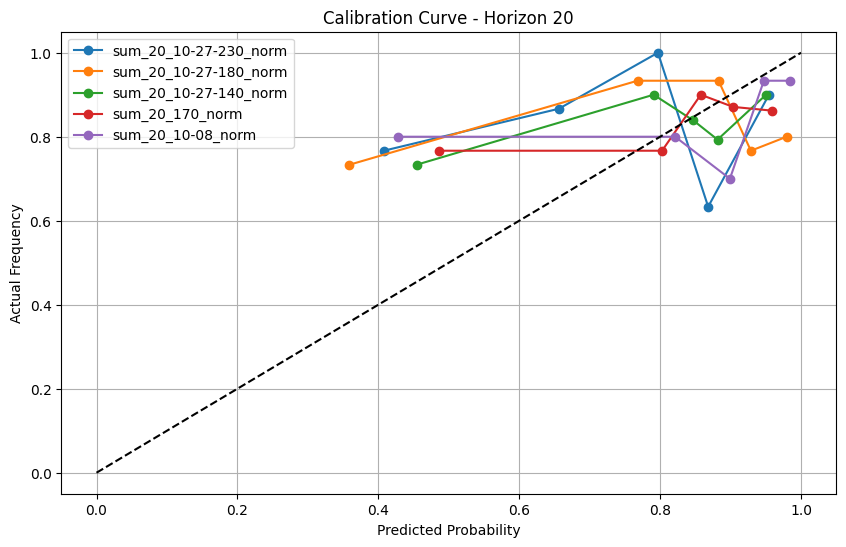

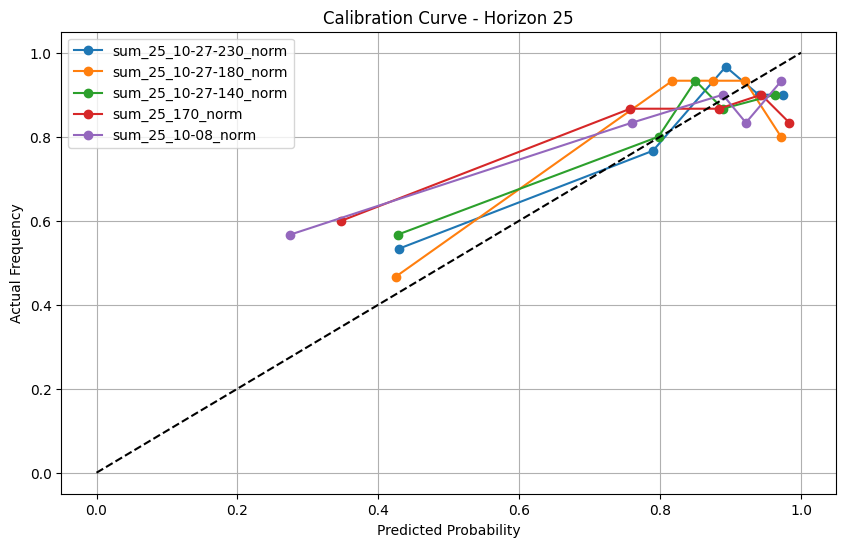

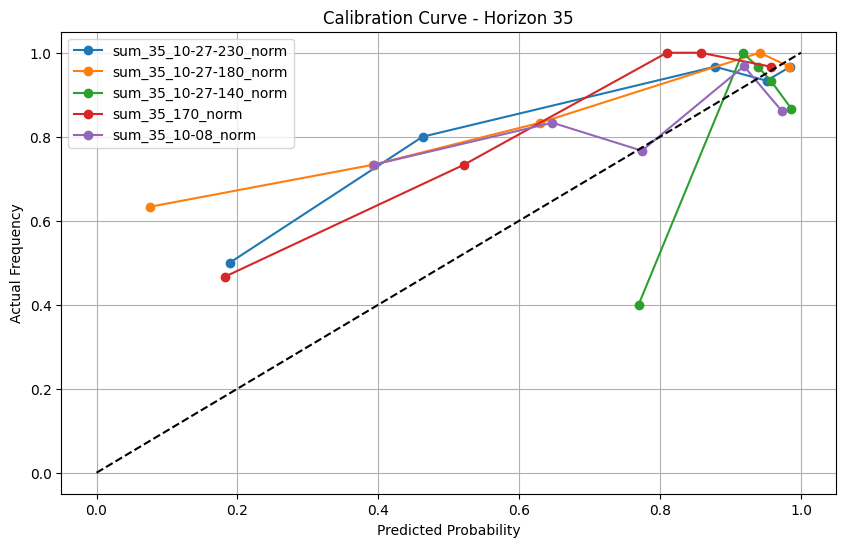

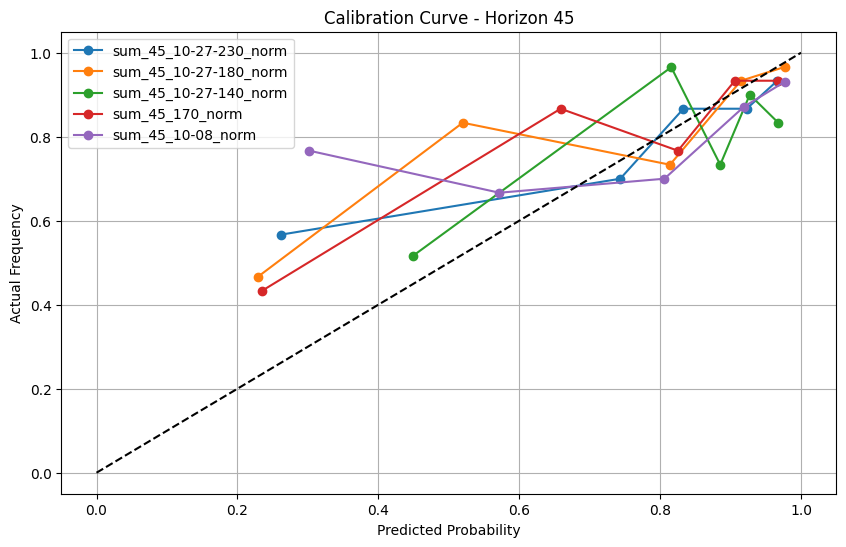

In [12]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)

def performance_metrics(metrics_df, returns):

    metrics_df = metrics_df.sort_index(ascending=True)

    def add_column_based_on_future_value(df, days):

        future_return = (df['Close'].shift(-days) - df['Close']) / df['Close']

        df[f'Return_{days}'] = (future_return > 0).astype(int)

        return df

    # Apply return logic for each target horizon
    for r in returns: 
        new_df = add_column_based_on_future_value(metrics_df, r)

    return new_df

performance_df = performance_metrics(combined_df.round(3), returns)

horizons = returns
# Dictionary to store the filtered DataFrames
horizon_dfs = {}

# Loop through each horizon
for h in horizons:
    # Collect relevant columns
    cols = ['Date', 'Close'] + [
        col for col in performance_df.columns 
        if col.endswith(f'_xgb_{h}deep') or col.endswith(f'_xgb_{h}shallow') or f'sum_{h}_' in col or col == f'Return_{h}']
    
    # Create and store the filtered DataFrame
    horizon_dfs[h] = performance_df[cols].copy()

def convert_signed_to_prob(p):
    return p if p >= 0 else 1 + p

def convert_sum_to_prob(p):
    return p if p >= 0 else -1 * p

for h in horizons:

    df = horizon_dfs[h].sort_values('Date', ascending=False).iloc[h:h+150].copy()
    for col in df.columns:
        if f'sum_{h}' in col:
            #df[f'{col}_norm'] = df[col] / 5
            max_pos = df.loc[df[col] > 0, col].max()
            max_neg = df.loc[df[col] < 0, col].min()  # most negative (e.g., -12.5)
            
            df[f'{col}_norm'] = df[col].apply(
                lambda x: x / max_pos if x > 0 else (x / abs(max_neg) if x < 0 else 0)
            )

    bins = [5]
    for bin in bins:
        # --- Calibration Curve ---
        plt.figure(figsize=(10, 6))
        for col in df.columns:
            if f'_xgb_{h}' in col or 'norm' in col: #f'sum_{h}_norm' in col:
                filtered = df[df[col] != 0]
                if 'norm' in col: #== f'sum_{h}_norm':
                    probs = filtered[col].apply(convert_sum_to_prob)
                else:
                    probs = filtered[col].apply(convert_signed_to_prob)
                targets = filtered[f'Return_{h}']
                prob_true, prob_pred = calibration_curve(targets, probs, n_bins=bin, strategy='quantile')
                plt.plot(prob_pred, prob_true, marker='o', label=col)

        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f'Calibration Curve - Horizon {h}')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Actual Frequency')
        plt.legend()
        plt.grid()
        plt.show()

In [15]:
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 10000)
pd.set_option("display.max_colwidth", None)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
threshs = [.5]
thresh = .55
length = 100
start = 0
accuracy_df, combined_df = pd.DataFrame(), pd.DataFrame()
df = extract(ticker, returns, raw_all, windows=[10,25])

def performance_metrics(metrics_df, returns):

    metrics_df = metrics_df.sort_index(ascending=True)

    def add_column_based_on_future_value(df, days):

        future_return = (df['Close'].shift(-days) - df['Close']) / df['Close']

        df[f'Return_{days}'] = (future_return > 0).astype(int)

        return df

    # Apply return logic for each target horizon
    for r in returns: 
        new_df = add_column_based_on_future_value(metrics_df, r)

    return new_df
    
for ext in exts:

    with open(f"curr_feature_map_v{ext}.pkl", "rb") as f:
            feature_map = pickle.load(f)

    # Run submodel
    sub_model_df, model_xgb, cols = submodel(thresh, ext, df)

    # Select only needed columns
    cols_to_merge = ['Date', 'Close', 
                    f'sum_5_{ext}', f'sum_10_{ext}', f'sum_15_{ext}', 
                    f'sum_20_{ext}', f'sum_25_{ext}', f'sum_35_{ext}', f'sum_45_{ext}']
    sub_model_df = sub_model_df[cols_to_merge]

    if combined_df.empty:
        combined_df = sub_model_df.copy()
    else:
        combined_df = combined_df.merge(sub_model_df, on=['Date', 'Close'], how='outer')

performance_df = performance_metrics(combined_df.round(3), returns)

horizons = returns
# Dictionary to store the filtered DataFrames
horizon_dfs = {}

# Loop through each horizon
for h in horizons:
    # Collect relevant columns
    cols = ['Date', 'Close'] + [
        col for col in performance_df.columns 
        if col.endswith(f'_xgb_{h}deep') or col.endswith(f'_xgb_{h}shallow') or f'sum_{h}' in col or col == f'Return_{h}'
    ]
    
    # Create and store the filtered DataFrame
    horizon_dfs[h] = performance_df[cols].copy()

for h in horizons:

    df = horizon_dfs[h].sort_values('Date', ascending=False).iloc[h+start:h+length+start].copy()
    
    for arch in ['deep']:
        records = []
        actual_pos = df[f'Return_{h}'].sum()
        actual_neg = len(df[f'Return_{h}']) - actual_pos
        for col in df.columns:
            if f'_xgb_{h}{arch}' in col or f'sum_{h}' in col:
                # only keep the rows that actually got a prediction
                filtered = df[df[col] != 0]
                # convert your raw score to a probability
                if f'sum_{h}' in col:
                    probs = filtered[col].apply(convert_sum_to_prob)
                else:
                    probs = filtered[col].apply(convert_signed_to_prob)
                # binarize at 0.5
                y_pred = (probs >= 0.5).astype(int)
                y_true = filtered[f'Return_{h}']
                
                # compute the matrix
                cm = confusion_matrix(y_true, y_pred,labels=[0,1])
                tn, fp, fn, tp = cm.ravel()
                records.append({
                    'horizon': h,
                    'model': col,
                    'act_pos': actual_pos,
                    'act_neg': actual_neg,
                    'pos_acc': f"{(tp/(tp + fp)):.1%}" if actual_pos>0 else "n/a",
                    'neg_acc': f"{(tn/(tn + fn)):.1%}" if actual_neg>0 else "n/a",
                    'tp': tp,
                    'fp': fp,
                    'tn': tn,
                    'fn': fn,
                })

        # make your summary table
        cm_df = pd.DataFrame(records)
        accuracy_df = pd.concat([accuracy_df, cm_df], ignore_index=True)

accuracy_df["pos_weight"] = (accuracy_df["pos_acc"].replace("n/a", "50%") .str.rstrip("%").astype(float).fillna(50).clip(lower=50) / 100)
accuracy_df["neg_weight"] = (accuracy_df["neg_acc"].replace("n/a", "50%") .str.rstrip("%").astype(float).fillna(50).clip(lower=50) / 100)
#accuracy_df[accuracy_df['horizon'] == 10]
pos_w_map = accuracy_df.groupby("model")["pos_weight"].mean().to_dict()
neg_w_map = accuracy_df.groupby("model")["neg_weight"].mean().to_dict()
accuracy_df

,horizon,model,act_pos,act_neg,pos_acc,neg_acc,tp,fp,tn,fn,pos_weight,neg_weight
0,5,sum_5_10-27-230,73,27,74.0%,50.0%,71,25,2,2,0.740,0.50
1,5,sum_5_10-27-180,73,27,75.8%,80.0%,72,23,4,1,0.758,0.80
2,5,sum_5_10-27-140,73,27,74.7%,75.0%,71,24,3,1,0.747,0.75
3,5,sum_5_170,73,27,72.9%,25.0%,70,26,1,3,0.729,0.50
4,5,sum_5_10-08,73,27,72.2%,0.0%,70,27,0,3,0.722,0.50
5,10,sum_10_10-27-230,82,18,85.6%,50.0%,77,13,5,5,0.856,0.50
6,10,sum_10_10-27-180,82,18,82.7%,50.0%,81,17,1,1,0.827,0.50
7,10,sum_10_10-27-140,82,18,84.8%,50.0%,78,14,4,4,0.848,0.50
8,10,sum_10_170,82,18,83.2%,40.0%,79,16,2,3,0.832,0.50
9,10,sum_10_10-08,82,18,82.7%,50.0%,81,17,1,1,0.827,0.50


In [81]:
horizons = returns
# Dictionary to store the filtered DataFrames
horizon_dfs = {}

# Loop through each horizon
for h in horizons:
    # Collect relevant columns
    cols = ['Date', 'Close'] + [
        col for col in performance_df.columns 
        if col.endswith(f'_xgb_{h}deep') or col.endswith(f'_xgb_{h}shallow') or f'sum_{h}' in col or col == f'Return_{h}'
    ]
    
    # Create and store the filtered DataFrame
    horizon_dfs[h] = performance_df[cols].copy()